![lop](../../images/logo_diive1_128px.png)

<span style='font-size:40px; display:block;'>
<b>
    Flux Processing Chain (here starting Level-4.1)
</b>
</br>
  
</span>
<p>Post-processing of EddyPro <i>_fluxnet_</i> output files</p>

---
**Notebook version**: `11.0` (19 Nov 2025)  
**Author**: Lukas Hörtnagl (holukas@ethz.ch)  

</br>

In [1]:
import pickle
from datetime import datetime
from diive.core.io.files import save_parquet, load_parquet

</br>

# Load previous `fpc` instance

In [2]:
# 1. Load the instance from the pickle file
file_path = '12_fpcInstance_IRGA72_LE-QCF11-USTNONE-L3.3.pkl'
with open(file_path, 'rb') as file:
    fpc = pickle.load(file)

In [3]:
fpc

</br>

</br>

<div style="
    height: 30px; /* Adjust height as desired */
    background: linear-gradient(135deg, #FF6B6B 0%, #FFE66D 100%); /* Warm gradient */
    background-image: 
        radial-gradient(circle at 100% 150%, #FF6B6B 0%, #FFE66D 100%),
        linear-gradient(to right, rgba(255,255,255,0.1) 1px, transparent 1px),
        linear-gradient(to bottom, rgba(255,255,255,0.1) 1px, transparent 1px);
    background-size: 100% 100%, 15px 15px, 15px 15px; /* Adjust pattern size */
    border-radius: 8px;
    box-shadow: 0 4px 8px rgba(0,0,0,0.1);
"></div>

# 🟢Level-4.1: GAP-FILLING

- Introduced in `diive` v0.85.0, gap-filling can now be done using both random forest and MDS
- For gap-filling using MDS, make sure that variables are in the required units: short-wave incoming radiation in `W m-2`, air temperature in `°C`, VPD in `hPa`

Parameters:
- `mds_settings` are parameters for the MDS gap-filling method, [see docstring here for more details](https://github.com/holukas/diive/blob/main/diive/pkgs/gapfilling/mds.py)
- `rf_settings` are parameters for scikit's `RandomForestRegressor` model, [see their official documentation for allowed parameters](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)
- `ml_feature_settings` are general settings for machine-learning models (such as random forest)

## 🔸Long-term random forest

In [4]:
FEATURES = ["TA_T1_47_1_gfXG", "SW_IN_T1_47_1_gfXG", "VPD_T1_47_1_gfXG"]
fpc.level41_longterm_random_forest(
    features=FEATURES,
    sanitize_timestamp=True,
    features_lag=[-1, -1],
    features_lag_stepsize=1,
    features_lag_exclude_cols=None,
    reduce_features=False,
    vectorize_timestamps=True,
    add_continuous_record_number=True,
    perm_n_repeats=10,
    verbose=True,
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=1,
    random_state=42,
)



Starting gap-filling for
LE_L3.1_L3.3_NONE_QCF
using <class 'sklearn.ensemble._forest.RandomForestRegressor'>

Adding new data columns ...
++ Added new columns with lagged variants for: ['TA_T1_47_1_gfXG', 'SW_IN_T1_47_1_gfXG', 'VPD_T1_47_1_gfXG'] (lags between -1 and -1 with stepsize 1), no lagged variants for: ['LE_L3.1_L3.3_NONE_QCF']. Shifting the time series created gaps which were then filled with the nearest value.
++ Added new columns with timestamp info: ['.YEAR', '.SEASON', '.SEASON_SIN', '.SEASON_COS', '.MONTH', '.MONTH_SIN', '.MONTH_COS', '.WEEK', '.WEEK_SIN', '.WEEK_COS', '.DOY', '.DOY_SIN', '.DOY_COS', '.HOUR', '.HOUR_SIN', '.HOUR_COS', '.YEARMONTH', '.YEARDOY', '.YEARWEEK'] 
++ Added new column .RECORDNUMBER with record numbers from 1 to 157824.

Sanitizing timestamp ...
>>> Validating timestamp naming of timestamp column TIMESTAMP_MIDDLE ... Timestamp name OK.
>>> Converting timestamp TIMESTAMP_MIDDLE to datetime ... OK
>>> All rows have timestamp TIMESTAMP_MIDDLE, no

## 🔸MDS (Marginal Distribution Sampling)

In [5]:
# fpc.level41_mds(
#     swin="SW_IN_T1_47_1_gfXG",
#     ta="TA_T1_47_1_gfXG",
#     vpd="VPD_T1_47_1_gfXG",
#     swin_tol=[20, 50],
#     ta_tol=2.5,
#     vpd_tol=0.5,
#     avg_min_n_vals=5
# )

## Get results
- Results from the flux processing chain can be accessed using `.get_data()`
- This returns a dataframe containing all input data and all newly generated variables, such as quality flags, quality-filtered fluxes and gap-filled fluxes

In [6]:
results = fpc.get_data(verbose=1)
results

NEW VARIABLES FROM FLUX PROCESSING CHAIN:
++ FLAG_L2_LE_MISSING_TEST
++ FLAG_L2_LE_SSITC_TEST
++ FLAG_L2_LE_SCF_TEST
++ FLAG_L2_LE_SIGNAL_STRENGTH_TEST
++ FLAG_L2_LE_H2O_VM97_SPIKE_HF_TEST
++ FLAG_L2_LE_H2O_VM97_DROPOUT_TEST
++ SUM_L2_LE_HARDFLAGS
++ SUM_L2_LE_SOFTFLAGS
++ SUM_L2_LE_FLAGS
++ FLAG_L2_LE_QCF
++ LE_L2_QCF
++ LE_L2_QCF0
++ SLE_SINGLE_gfRMED_L3.1
++ FLAG_SLE_SINGLE_gfRMED_L3.1_ISFILLED
++ LE_L3.1
++ LE_L3.1_QCF
++ LE_L3.1_QCF0
++ FLAG_L3.2_LE_L3.1_QCF_OUTLIER_MANUAL_TEST
++ FLAG_L3.2_LE_L3.1_QCF_OUTLIER_HAMPELDTNT_TEST
++ FLAG_L3.2_LE_L3.1_QCF_OUTLIER_HAMPELDTNT_2_TEST
++ FLAG_L3.2_LE_L3.1_QCF_OUTLIER_ABSLIM_TEST
++ FLAG_L3.2_LE_L3.1_QCF_OUTLIER_LOCALSD_TEST
++ SUM_L3.2_LE_L3.1_HARDFLAGS
++ SUM_L3.2_LE_L3.1_SOFTFLAGS
++ SUM_L3.2_LE_L3.1_FLAGS
++ FLAG_L3.2_LE_L3.1_QCF
++ LE_L3.1_L3.2_QCF
++ LE_L3.1_L3.2_QCF0
++ FLAG_L3.3_NONE_LE_L3.1_USTAR_TEST
++ SUM_L3.3_NONE_LE_L3.1_HARDFLAGS
++ SUM_L3.3_NONE_LE_L3.1_SOFTFLAGS
++ SUM_L3.3_NONE_LE_L3.1_FLAGS
++ FLAG_L3.3_NONE_LE_L3.1_QCF
+

,AIR_CP,AIR_DENSITY,AIR_MV,AIR_RHO_CP,AOA_METHOD,AXES_ROTATION_METHOD,...,SUM_L3.3_NONE_LE_L3.1_FLAGS,FLAG_L3.3_NONE_LE_L3.1_QCF,LE_L3.1_L3.3_NONE_QCF,LE_L3.1_L3.3_NONE_QCF0,LE_L3.1_L3.3_NONE_QCF_gfRF,FLAG_LE_L3.1_L3.3_NONE_QCF_gfRF_ISFILLED
TIMESTAMP_MIDDLE,,,,,,,,,,,,,
2016-01-01 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,2.0,NaN,NaN,-3.649502,1
2016-01-01 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,2.0,NaN,NaN,-3.649502,1
2016-01-01 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,2.0,NaN,NaN,-3.190653,1
2016-01-01 01:45:00,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,2.0,NaN,NaN,-2.525330,1
2016-01-01 02:15:00,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,2.0,NaN,NaN,-2.407218,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 21:45:00,1008.09,1.20135,0.024060,1211.07,0.0,1.0,...,2.0,2.0,NaN,NaN,8.808219,1
2024-12-31 22:15:00,1008.14,1.20010,0.024085,1209.87,0.0,1.0,...,1.0,1.0,2.28642,NaN,2.286420,0
2024-12-31 22:45:00,1008.20,1.20023,0.024081,1210.07,0.0,1.0,...,2.0,2.0,NaN,NaN,3.770891,1


## Model scores

### Model scores and details on test data

In [7]:
# Show train/test details
print(fpc.report_traintest_model_scores())
print(fpc.report_traintest_details())
# fpc.report_traintest_model_scores(outpath=".")  # Save in current folder
# fpc.report_traintest_details(outpath=".")  # Save in current folder


MODEL SCORES from TRAINING/TESTING (long_term_random_forest): 
 trained on training data, tested on unseen test data NONE
              2016         2017         2018         2019         2020         2021         2022         2023         2024
mae      27.117687    27.117687    26.713113    25.637137    25.664757    25.610022    25.849718    25.417804    25.417804
medae    13.603906    13.603906    13.580663    13.942805    13.318707    13.118482    12.588785    12.523713    12.523713
mse    2081.592027  2081.592027  2007.411144  1768.246978  1859.748130  1835.051211  1895.490887  1845.922740  1845.922740
rmse     45.624467    45.624467    44.804142    42.050529    43.124797    42.837498    43.537236    42.964203    42.964203
mape      3.409582     3.409582     2.729406     3.047782     2.680957     3.515102     3.177539     6.328284     6.328284
maxe    350.845721   350.845721   378.530884   498.507935   484.727169   365.679915   466.369734   362.329877   362.329877
r2        0.8110

### Model scores on all data

In [8]:
fpc.report_gapfilling_model_scores()
# fpc.report_gapfilling_model_scores(outpath=".")  # Save in current folder


MODEL SCORES (long_term_random_forest): NONE
             2016        2017        2018        2019        2020        2021        2022        2023        2024
mae     14.017833   14.017833   14.108193   13.627448   13.476723   13.477318   13.331265   13.492887   13.492887
medae    6.073626    6.073626    6.338006    6.301231    6.023674    5.933665    5.733911    5.914310    5.914310
mse    724.311316  724.311316  709.815762  633.883311  655.906529  652.139748  657.741380  657.175086  657.175086
rmse    26.913032   26.913032   26.642368   25.177039   25.610672   25.537027   25.646469   25.635426   25.635426
mape     1.683671    1.683671    2.247414    2.320991    2.196166    1.619022    1.629090    2.540552    2.540552
maxe   350.845721  350.845721  378.530884  498.507935  484.727169  365.679915  466.369734  362.329877  362.329877
r2       0.932781    0.932781    0.930744    0.932149    0.934429    0.931090    0.931309    0.935105    0.935105


During long-term gap-filling, different years are pooled together to predict one central year, i.e., multiple models are used.  
The used data pools can be display with:

In [9]:
fpc.report_gapfilling_poolyears()

DATA POOLS USED FOR MACHINE-LEARNING GAP-FILLING:
2016: long_term_random_forest used data from [2016, 2017, 2018] for gap-filling LE_L3.1_L3.3_NONE_QCF and producing --> LE_L3.1_L3.3_NONE_QCF_gfRF
2017: long_term_random_forest used data from [2016, 2017, 2018] for gap-filling LE_L3.1_L3.3_NONE_QCF and producing --> LE_L3.1_L3.3_NONE_QCF_gfRF
2018: long_term_random_forest used data from [2017, 2018, 2019] for gap-filling LE_L3.1_L3.3_NONE_QCF and producing --> LE_L3.1_L3.3_NONE_QCF_gfRF
2019: long_term_random_forest used data from [2018, 2019, 2020] for gap-filling LE_L3.1_L3.3_NONE_QCF and producing --> LE_L3.1_L3.3_NONE_QCF_gfRF
2020: long_term_random_forest used data from [2019, 2020, 2021] for gap-filling LE_L3.1_L3.3_NONE_QCF and producing --> LE_L3.1_L3.3_NONE_QCF_gfRF
2021: long_term_random_forest used data from [2020, 2021, 2022] for gap-filling LE_L3.1_L3.3_NONE_QCF and producing --> LE_L3.1_L3.3_NONE_QCF_gfRF
2022: long_term_random_forest used data from [2021, 2022, 2023] for 

In [10]:
fpc.report_gapfilling_feature_importances()  # Save in current folder
# fpc.report_gapfilling_feature_importances(outpath=".")  # Save in current folder


FEATURE IMPORTANCES (long_term_random_forest): NONE
YEAR                       2016      2017      2018      2019      2020      2021      2022      2023      2024
FEATURE                                                                                                        
SW_IN_T1_47_1_gfXG     0.778619  0.778619  0.712609  0.756640  0.895281  0.814739  0.714529  0.971551  0.971551
.SW_IN_T1_47_1_gfXG-1  0.686961  0.686961  0.419408  0.182379  0.096004  0.115381  0.276295  0.158107  0.158107
.WEEK_COS              0.107400  0.107400  0.003986  0.003439  0.006069  0.010353  0.004861  0.004467  0.004467
TA_T1_47_1_gfXG        0.089115  0.089115  0.111658  0.116648  0.115353  0.276878  0.216599  0.091601  0.091601
.TA_T1_47_1_gfXG-1     0.067000  0.067000  0.028498  0.029411  0.042938  0.035076  0.035968  0.065244  0.065244
.RECORDNUMBER          0.049054  0.049054  0.054991  0.056035  0.042339  0.074439  0.077624  0.088127  0.088127
.DOY_COS               0.048381  0.048381  0.062409

## Names of gap-filled variables


In [11]:
print("Used model, USTAR scenario, non-gapfilled variable and gap-filled variable:")
fpc.report_gapfilling_variables()

Used model, USTAR scenario, non-gapfilled variable and gap-filled variable:
long_term_random_forest (NONE): LE_L3.1_L3.3_NONE_QCF -> LE_L3.1_L3.3_NONE_QCF_gfRF


In [12]:
gapfilled_names = fpc.get_gapfilled_names()
gapfilled_names

['LE_L3.1_L3.3_NONE_QCF_gfRF']

Gap-filled data can also be accessed directly. To get all gap-filled variables and also the same variables before gap-filling in a dataframe, use `.get_gapfilled_variables()`: 

In [13]:
gapfilled_vars = fpc.get_gapfilled_variables()
gapfilled_vars.head(3)

,LE_L3.1_L3.3_NONE_QCF_gfRF,LE_L3.1_L3.3_NONE_QCF
TIMESTAMP_MIDDLE,,
2016-01-01 00:15:00,-3.649502,NaN
2016-01-01 00:45:00,-3.649502,NaN
2016-01-01 01:15:00,-3.190653,NaN


The names of the flux that was gap-filled can be accessed like this:

In [14]:
nongapfilled_names = fpc.get_nongapfilled_names()
nongapfilled_names

['LE_L3.1_L3.3_NONE_QCF']

## Plots

### Heatmaps

F:\Sync\luhk_work\20 - CODING\21 - DIIVE\diive\diive\pkgs\fluxprocessingchain\fluxprocessingchain.py:502: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


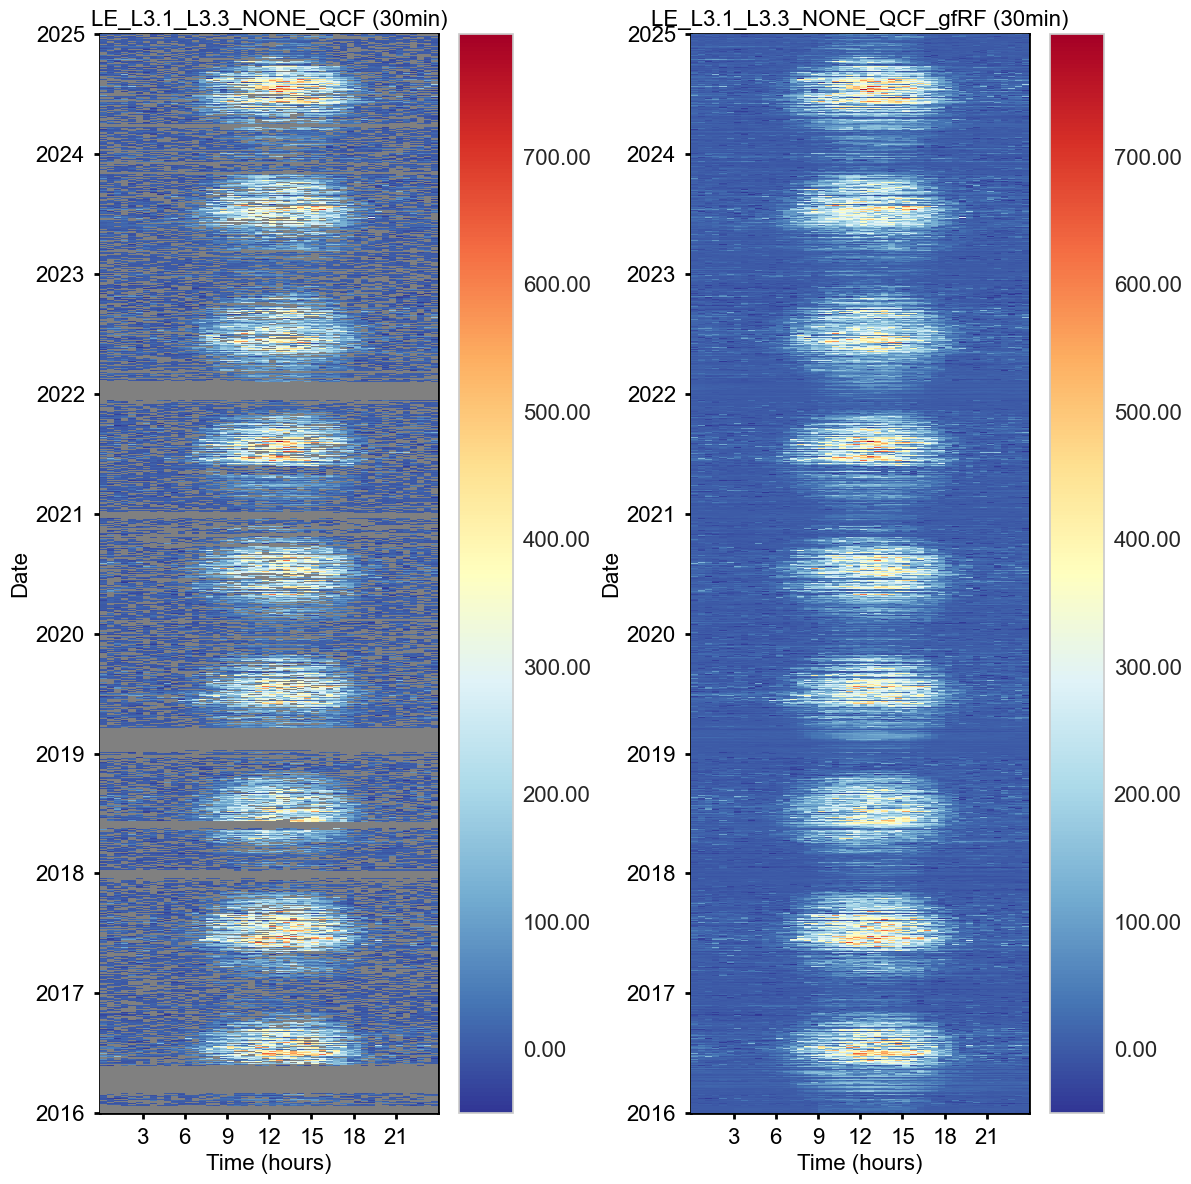

In [15]:
fpc.showplot_gapfilled_heatmap()

### Cumulatives per year

F:\Sync\luhk_work\20 - CODING\21 - DIIVE\diive\diive\core\plotting\cumulative.py:145: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  self.fig.show()


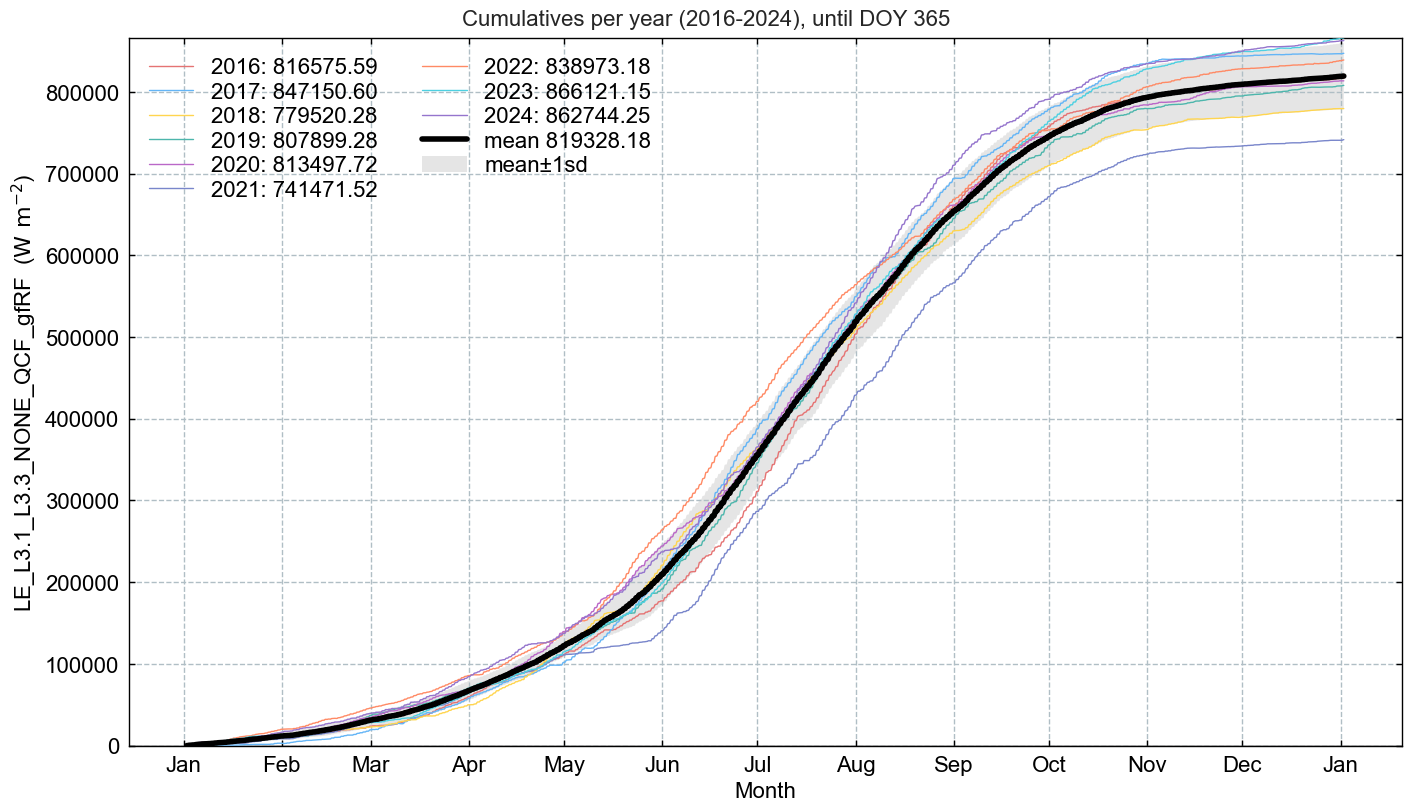

In [16]:
fpc.showplot_gapfilled_cumulative(gain=1, units=r'($\mathrm{W\ m^{-2}}$)', per_year=True)

### Cumulative across all data 

F:\Sync\luhk_work\20 - CODING\21 - DIIVE\diive\diive\core\plotting\cumulative.py:251: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  self.fig.show()


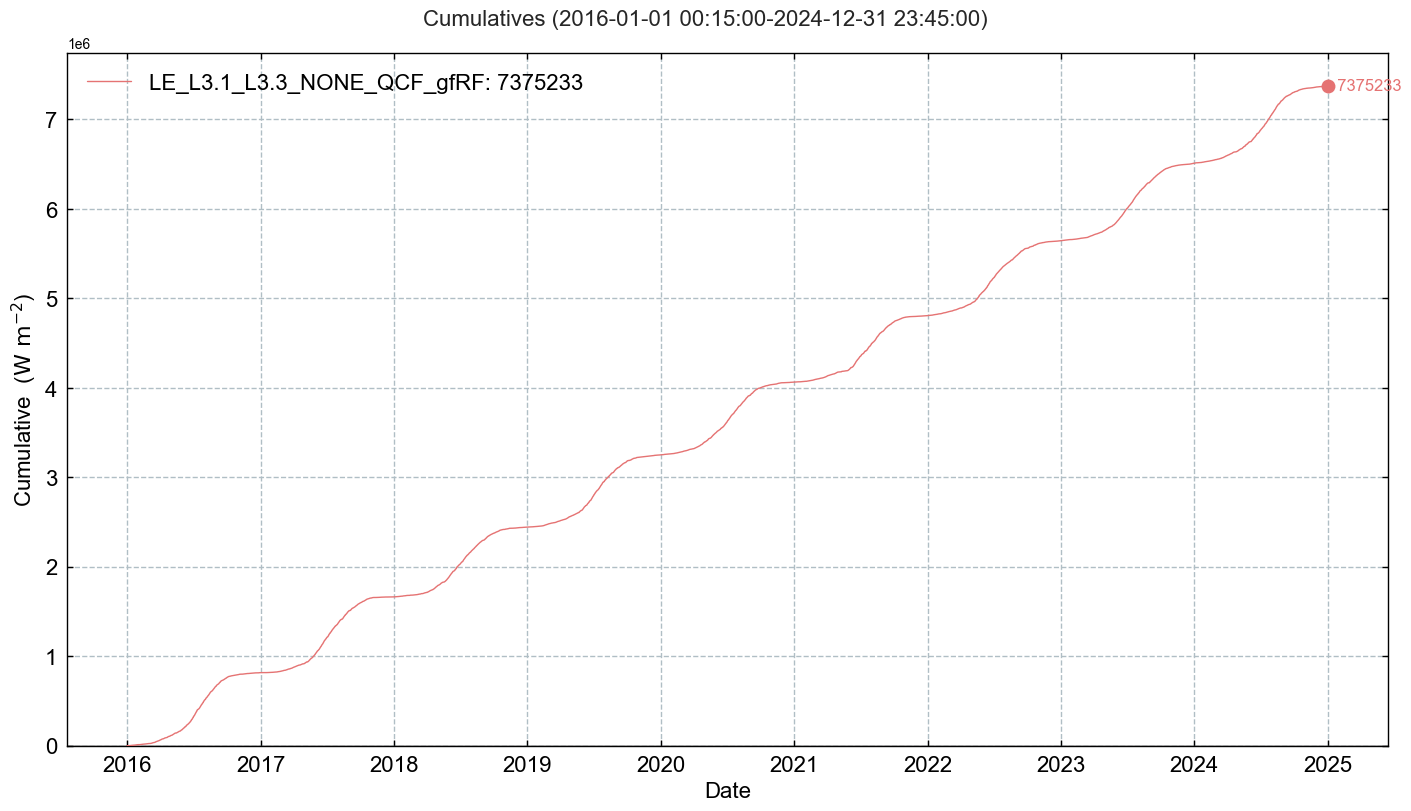

In [23]:
fpc.showplot_gapfilled_cumulative(gain=1, units=r'($\mathrm{W\ m^{-2}}$)', per_year=False)

### ML Feature ranks per year (machine learning models only)

F:\Sync\luhk_work\20 - CODING\21 - DIIVE\diive\diive\pkgs\gapfilling\longterm.py:268: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.plot(row.index, row.values, "o", marker=verts, ms=20,
F:\Sync\luhk_work\20 - CODING\21 - DIIVE\diive\diive\pkgs\gapfilling\longterm.py:287: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


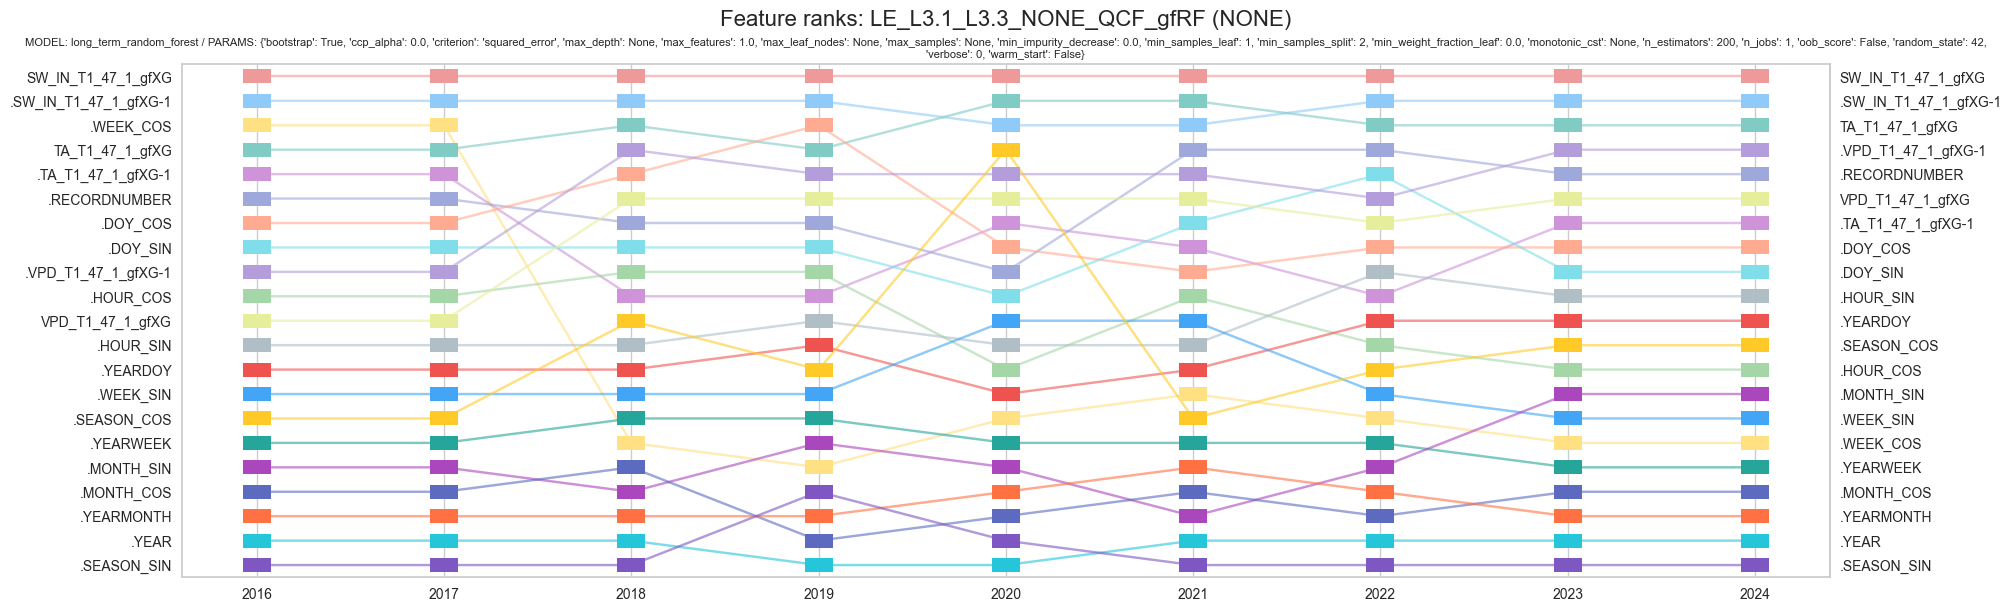

In [18]:
fpc.showplot_feature_ranks_per_year()

### MDS gap-filling qualities (MDS only, otherwise skipped)

In [19]:
fpc.showplot_mds_gapfilling_qualities()

</br>

</br>

<div style="
    height: 30px; /* Adjust height as desired */
    background: linear-gradient(135deg, #FF6B6B 0%, #FFE66D 100%); /* Warm gradient */
    background-image: 
        radial-gradient(circle at 100% 150%, #FF6B6B 0%, #FFE66D 100%),
        linear-gradient(to right, rgba(255,255,255,0.1) 1px, transparent 1px),
        linear-gradient(to bottom, rgba(255,255,255,0.1) 1px, transparent 1px);
    background-size: 100% 100%, 15px 15px, 15px 15px; /* Adjust pattern size */
    border-radius: 8px;
    box-shadow: 0 4px 8px rgba(0,0,0,0.1);
"></div>

# SAVE RESULTS TO FILE

- Save results to file for futher processing
- This can be useful if you want to use the data in another software, e.g. continuing post-processing using the library `ReddyProc` in `R` 
- `Parquet` format is recommended for large datasets

</br>

## Option 1: Save complete data (input data and results) to CSV (large and slow)

In [20]:
# results.to_csv("FluxProcessingChain_L4.1.csv")

</br>

## Option 2: Save input data and results to Parquet (small and fast)
- Needed if you want to continue post-processing in notebooks
- Can also be used in `R` with the `arrow` package

In [21]:
save_parquet(data=results, filename="14_FPC_IRGA72_LE-QCF11-USTNONE-L4.1-RF")

Saved file 14_FPC_IRGA72_LE-QCF11-USTNONE-L4.1-RF.parquet (3.617 seconds).


'14_FPC_IRGA72_LE-QCF11-USTNONE-L4.1-RF.parquet'

</br>

</br>

<div style="
    height: 30px; /* Adjust height as desired */
    background: linear-gradient(135deg, #FF6B6B 0%, #FFE66D 100%); /* Warm gradient */
    background-image: 
        radial-gradient(circle at 100% 150%, #FF6B6B 0%, #FFE66D 100%),
        linear-gradient(to right, rgba(255,255,255,0.1) 1px, transparent 1px),
        linear-gradient(to bottom, rgba(255,255,255,0.1) 1px, transparent 1px);
    background-size: 100% 100%, 15px 15px, 15px 15px; /* Adjust pattern size */
    border-radius: 8px;
    box-shadow: 0 4px 8px rgba(0,0,0,0.1);
"></div>

# ✅END OF NOTEBOOK

Congratulations, you reached the end of this notebook! Before you go let's store your finish time.

In [22]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-12-07 00:27:36
